# Gráfico Momento-Curvatura

Genera el gráfico Momento-Curvatura que viene del Section Designer de SAP2000.

Requiere tener copiado en el portapapeles los datos antes de ejecutar.

In [16]:
# Código para exportar a html sin mostrar el código input.
# jupyter nbconvert --to html notebooks\Hormigon\viga_ACI318.ipynb --no-input

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Leer desde el portapapeles, con tabulaciones como separadores y coma como decimal, sin encabezados
df = pd.read_clipboard(sep='\t', decimal=',', header=None)

col1 = df.iloc[:, 0].to_numpy()
col2 = df.iloc[:, 1].to_numpy()*0.95
col3 = df.iloc[:, 2].to_numpy()*0.9
col4 = df.iloc[:, 3].to_numpy()

#Agregar valores 0 al inicio de las columnas
col1 = np.insert(col1, 0, 0)
col2 = np.insert(col2, 0, 0)
col3 = np.insert(col3, 0, 0)
col4 = np.insert(col4, 0, 0)

# print(f"Filas leídas: {len(df)}")
# print(f"col1[:3] = {col1[:3]}")
# print(f"col2[:3] = {col2[:3]}")
# print(f"col3[:3] = {col3[:3]}")
# print(f"col4[:3] = {col4[:3]}")

## Momento Ultimo y Momento de Fluencia

In [18]:
M_ult = 80.0 #tonf-m

M_yield =col2[1] #tonf-m


In [19]:
tabla = pd.DataFrame({
    'Momento de Fluencia (tonf-m)': [M_yield],
    'Momento Ultimo (tonf-m)': [M_ult],
    'FU': [M_ult/M_yield]
})

#tabla para mostrar resultados en formato de tabla con bordes
styles = [
    dict(selector="th", props=[("border", "1px solid black")]),
    dict(selector="td", props=[("border", "1px solid black")])
]

#tabla sin columna de indices
tabla = tabla.set_index(pd.Index(['']))

tabla = tabla.style.set_table_styles(styles).set_properties(**{'border': '1px solid black', 'border-collapse': 'collapse'})
#centrado
tabla = tabla.set_properties(**{'text-align': 'center'})
#2 decimales
tabla = tabla.format(precision=2)
display(tabla)

,Momento de Fluencia (tonf-m),Momento Ultimo (tonf-m),FU
,148.63,80.00,0.54


<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
C:\Users\francisco.carrasco\AppData\Local\Temp\ipykernel_15732\1670900014.py:11: SyntaxWarning: invalid escape sequence '\p'
  plt.legend([f'$\phi M_n$ Real {M_yield:.2f}', '$\phi M_n$ Ideal', f'$\phi M_u$ Ultimo {M_ult:.2f}'])
C:\Users\francisco.carrasco\AppData\Local\Temp\ipykernel_15732\1670900014.py:11: SyntaxWarning: invalid escape sequence '\p'
  plt.legend([f'$\phi M_n$ Real {M_yield:.2f}', '$\phi M_n$ Ideal', f'$\phi M_u$ Ultimo {M_ult:.2f}'])
C:\Users\francisco.carrasco\AppData\Local\Temp\ipykernel_15732\1670900014.py:11: SyntaxWarning: invalid escape sequence '\p'
  plt.legend([f'$\phi M_n$ Real {M_yield:.2f}', '$\phi M_n$ Ideal', f'$\phi M_u$ Ultimo {M_ult:.2f}'])


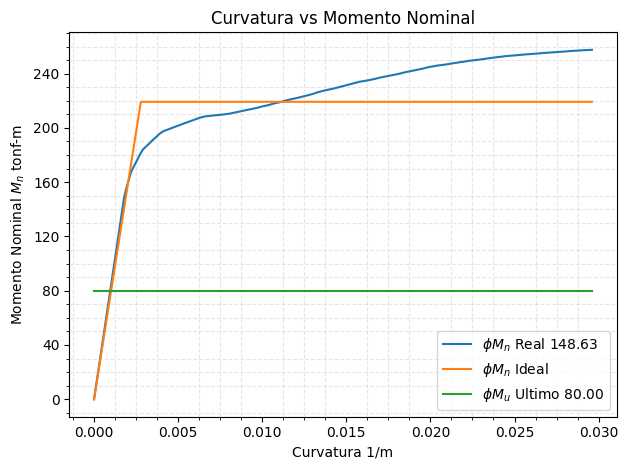

In [20]:
#grafico de lineas col1 vs col2
plt.plot(col1, col2, label='col1 vs col2')
plt.plot(col1, col3, label='col1 vs col3')
plt.plot(col1, [M_ult]*len(col1), label='Momento Ultimo $M_n$')

#nombre de ejes
plt.xlabel('Curvatura 1/m')
plt.ylabel('Momento Nominal $M_n$ tonf-m')

#leyenda personalizada
plt.legend([f'$\phi M_n$ Real {M_yield:.2f}', '$\phi M_n$ Ideal', f'$\phi M_u$ Ultimo {M_ult:.2f}'])


#titulo del grafico
plt.title('Curvatura vs Momento Nominal')

#ajustar valores de los ejes

from matplotlib.ticker import MaxNLocator, AutoMinorLocator

ax = plt.gca()
ax.relim(); ax.autoscale_view()
ax.xaxis.set_major_locator(MaxNLocator(nbins=8))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.grid(which='major', alpha=0.7)
ax.grid(which='minor', alpha=0.3, linestyle='--')
plt.tight_layout()

#cuadricula
plt.grid()

#mostrar grafico
plt.show()